In [1]:
import numpy as np
import argparse
import os
import importlib

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [2]:
import simulate_CCE

--------------------------------
CCE simulation
--------------------------------
seed = 1
T_ann = 623
t_ann = 1080
alpha = 1.6e-11
--------------------------------


In [3]:
importlib.reload(simulate_CCE)

--------------------------------
CCE simulation
--------------------------------
seed = 1
T_ann = 623
t_ann = 1080
alpha = 1.6e-11
--------------------------------


<module 'simulate_CCE' from '/global/u2/r/ritaferi/CTM/CCE/Li_grid/simulate_CCE.py'>

In [32]:
simulate_CCE.args = argparse.Namespace(

    seed=1,

    N_charges=250,

    N_repeat=400,

    alpha=5e-10,

    T_ann=473.15,

    t_ann=7200,

    output="library"

)

In [33]:
# litio
cells, saturation_depth, px, py, pz = simulate_CCE.generate_lithium()

print("Numero Li:", len(px))
print("Profondità saturazione:", saturation_depth*10, "mm")



Generating Li distribution...
Saturation depth = 0.66 mm


Li slices: 100%|██████████| 66/66 [00:00<00:00, 5186.79it/s]

Total Li particles = 1253
Numero Li: 1253
Profondità saturazione: 0.66 mm


In [34]:
x, CCE_matrix, CCE_mean, CCE_std = simulate_CCE.simulate_CCE(
    cells,
    saturation_depth,
    px,
    py,
    pz
)


Starting CCE simulation...



CCE depth:   0%|          | 0/21 [00:00<?, ?it/s]

Charge intial position: 0.0


CCE depth:   5%|▍         | 1/21 [00:00<00:07,  2.68it/s]

Charge intial position: 0.005


...

CCE depth:  90%|█████████ | 19/21 [13:35<01:20, 40.44s/it]

Charge intial position: 0.095


CCE depth:  95%|█████████▌| 20/21 [13:47<00:31, 31.95s/it]

Charge intial position: 0.1


CCE depth: 100%|██████████| 21/21 [13:49<00:00, 39.52s/it]


In [35]:
'''
import os

os.makedirs("library", exist_ok=True)


np.savez(
    "library/curve_000001.npz",

    x=x,

    CCE=CCE_matrix,

    CCE_mean=CCE_mean,

    CCE_std=CCE_std,

    particle_x=px,

    particle_y=py,

    particle_z=pz,

    seed=1,

    N_charges=250,

    N_repeat=250,

    alpha=simulate_CCE.alpha,

    T_ann=simulate_CCE.T_ann,

    t_ann=simulate_CCE.t_ann,

    saturation_depth=saturation_depth
)


print("creato library/curve_000001.npz")'''

'\nimport os\n\nos.makedirs("library", exist_ok=True)\n\n\nnp.savez(\n    "library/curve_000001.npz",\n\n    x=x,\n\n    CCE=CCE_matrix,\n\n    CCE_mean=CCE_mean,\n\n    CCE_std=CCE_std,\n\n    particle_x=px,\n\n    particle_y=py,\n\n    particle_z=pz,\n\n    seed=1,\n\n    N_charges=250,\n\n    N_repeat=250,\n\n    alpha=simulate_CCE.alpha,\n\n    T_ann=simulate_CCE.T_ann,\n\n    t_ann=simulate_CCE.t_ann,\n\n    saturation_depth=saturation_depth\n)\n\n\nprint("creato library/curve_000001.npz")'

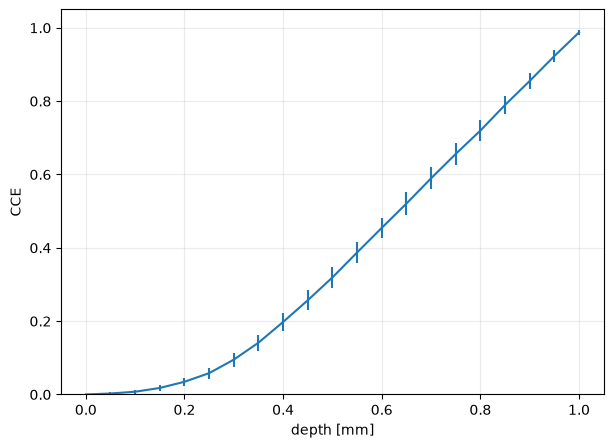

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.errorbar(
    x*10,
    CCE_mean,
    yerr = CCE_std)

plt.xlabel("depth [mm]")
plt.ylabel("CCE")

plt.ylim(0,1.05)

plt.grid(alpha = 0.25)

plt.show()

In [37]:
CCE_matrix.shape

(21, 400)

In [38]:
CCE_matrix.shape[1]

400

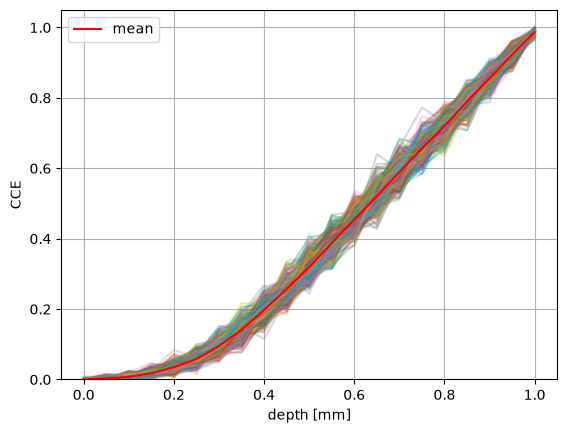

In [39]:


for j in range(CCE_matrix.shape[1]):

    plt.plot(
        x*10,
        CCE_matrix[:,j],
        alpha=0.3
    )


# media
plt.plot(
    x*10,
    CCE_mean,
    linewidth=1.5,
    label="mean",
    color = 'red'
)


plt.xlabel("depth [mm]")
plt.ylabel("CCE")

plt.ylim(0,1.05)

plt.grid()

plt.legend()

plt.show()

In [40]:
CCE_matrix

array([[0.   , 0.   , 0.   , ..., 0.   , 0.   , 0.   ],
       [0.004, 0.004, 0.004, ..., 0.   , 0.   , 0.   ],
       [0.012, 0.008, 0.008, ..., 0.004, 0.016, 0.004],
       ...,
       [0.852, 0.856, 0.872, ..., 0.856, 0.852, 0.832],
       [0.956, 0.92 , 0.924, ..., 0.924, 0.92 , 0.908],
       [0.988, 0.988, 0.972, ..., 0.992, 0.988, 0.992]], shape=(21, 400))

In [41]:
# prendiamo tutti i punti delle curve
X = np.repeat(
    x*10,CCE_mean,
    CCE_matrix.shape[1]
)


Y = CCE_matrix.flatten()



plt.figure(figsize=(8,6))


# istogramma 2D
h = plt.hist2d(

    X,
    Y,

    bins=[
        len(x),
        200
    ],

    cmap="viridis"

)

plt.vlines(0.27,0,1, color = 'grey', alpha = 0.25, ls = '--', label = 'RDR = 0.27 mm')

# CCE=0 bianco
plt.gca().set_ylim(0,1.05)
# media
plt.errorbar(
    x*10,
    CCE_mean,
    yerr = CCE_std, 
    linewidth=1.5,
    label="mean",
    color = 'red'
)

# cambio colore dello zero
h[3].cmap.set_under("white")

h[3].set_clim(
    vmin=1
)


plt.colorbar(
    label="counts"
)


plt.xlabel(
    "depth [mm]"
)

plt.ylabel(
    "CCE"
)


plt.title(
    "CCE density map"
)

plt.savefig("densità.png", dpi = 300)
plt.show()

TypeError: Cannot cast array data from dtype('float64') to dtype('int64') according to the rule 'safe'

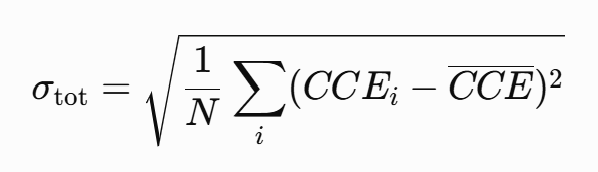

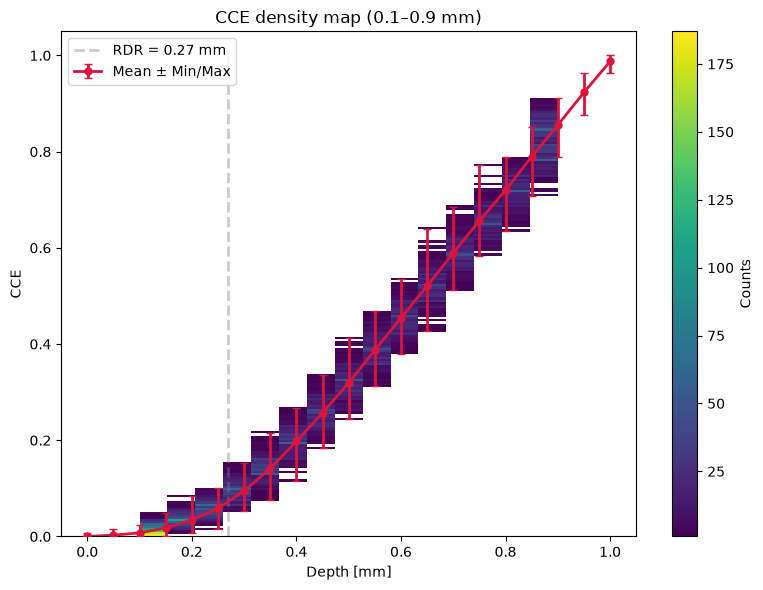

In [42]:
# prendiamo tutti i punti delle curve
X = np.repeat(
    x * 10,
    CCE_matrix.shape[1]
)

Y = CCE_matrix.flatten()

# selezioniamo solo la regione 0.1 - 0.9 mm
mask = (X >= 0.1) & (X <= 0.9)

X_cut = X[mask]
Y_cut = Y[mask]

plt.figure(figsize=(8,6))

# istogramma 2D
h = plt.hist2d(
    X_cut,
    Y_cut,
    bins=[15, 200],
    cmap="viridis"
)

# linea RDR
plt.vlines(
    0.27,
    0,
    1,
    color="grey",
    alpha=0.4,
    linestyle="--",
    linewidth=2,
    label="RDR = 0.27 mm"
)

# limiti asse y
plt.ylim(0, 1.05)

# media
CCE_mean = np.mean(CCE_matrix, axis=1)

# minimo e massimo ad ogni profondità
CCE_min = np.min(CCE_matrix, axis=1)
CCE_max = np.max(CCE_matrix, axis=1)

# barre d'errore asimmetriche (min-max)
plt.errorbar(
    x * 10,
    CCE_mean,
    yerr=[
        CCE_mean - CCE_min,
        CCE_max - CCE_mean
    ],
    fmt="o-",
    color="crimson",
    linewidth=2,
    markersize=5,
    capsize=3,
    zorder=10,
    label="Mean ± Min/Max"
)

# celle vuote bianche
h[3].cmap.set_under("white")
h[3].set_clim(vmin=1)

plt.colorbar(label="Counts")

plt.xlabel("Depth [mm]")
plt.ylabel("CCE")

plt.title("CCE density map (0.1–0.9 mm)")

plt.legend(loc="upper left")

plt.tight_layout()

plt.savefig("density_01_09.png", dpi=300)

plt.show()

In [16]:
# quanod dovrò prendere la distirbuzion 
# CCE_sample = np.random.normal( CCE_mean, CCE_width )

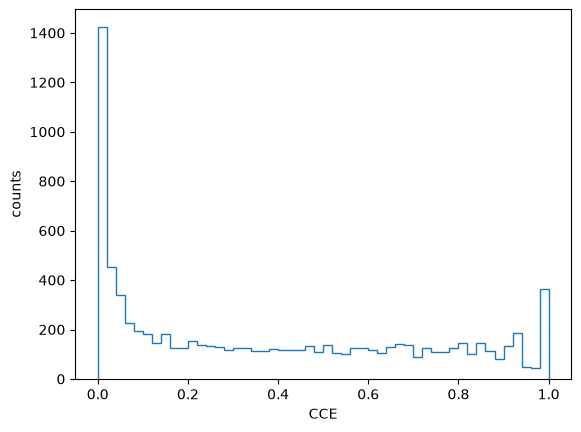

In [43]:
plt.hist(
    CCE_matrix.flatten(),
    bins=50,
    histtype="step"
)
# sono tutti i CCE indipendentemente dalla posizione
plt.xlabel("CCE")
plt.ylabel("counts")
plt.show()

In [44]:
np.arange(0,21,1) 

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20])

x = 0.200 mm  -->  sigma_CCE = 0.01142
x = 0.300 mm  -->  sigma_CCE = 0.01914
x = 0.400 mm  -->  sigma_CCE = 0.02463
x = 0.500 mm  -->  sigma_CCE = 0.02944
x = 0.600 mm  -->  sigma_CCE = 0.02774
x = 0.700 mm  -->  sigma_CCE = 0.02982
x = 0.800 mm  -->  sigma_CCE = 0.02853
x = 0.900 mm  -->  sigma_CCE = 0.02111
x = 1.000 mm  -->  sigma_CCE = 0.00687


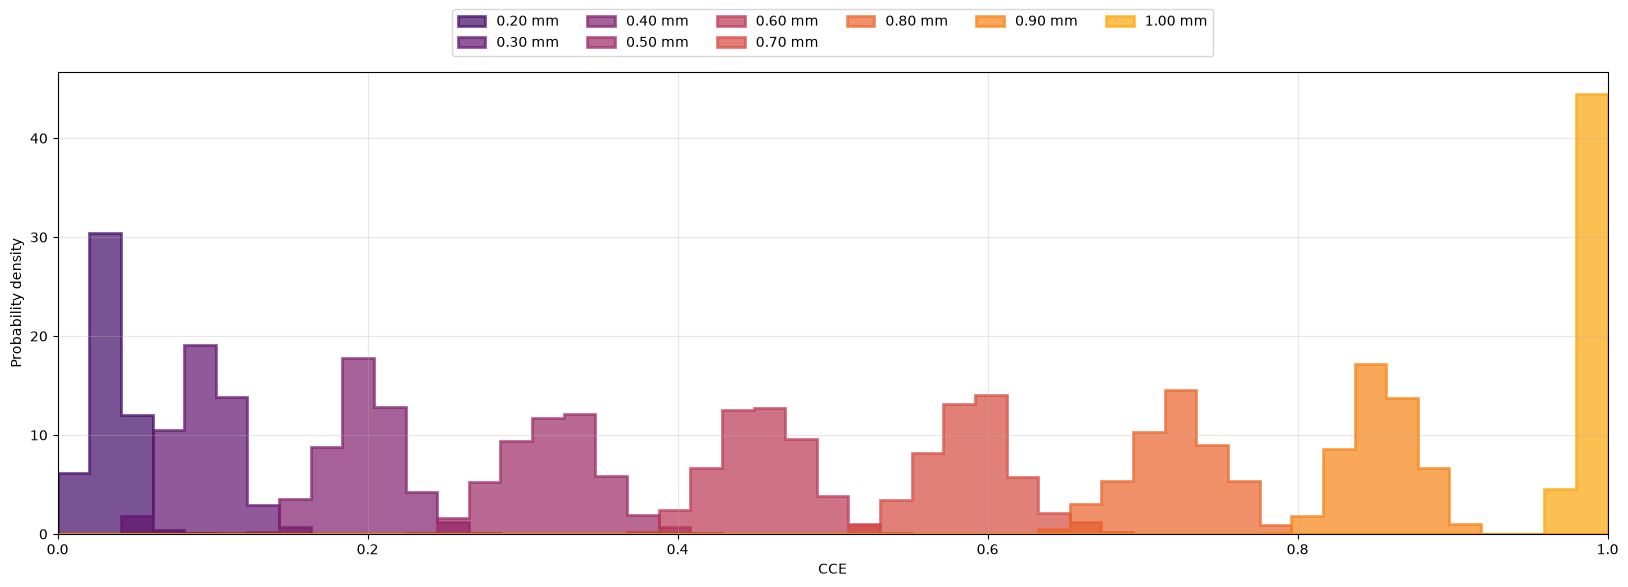

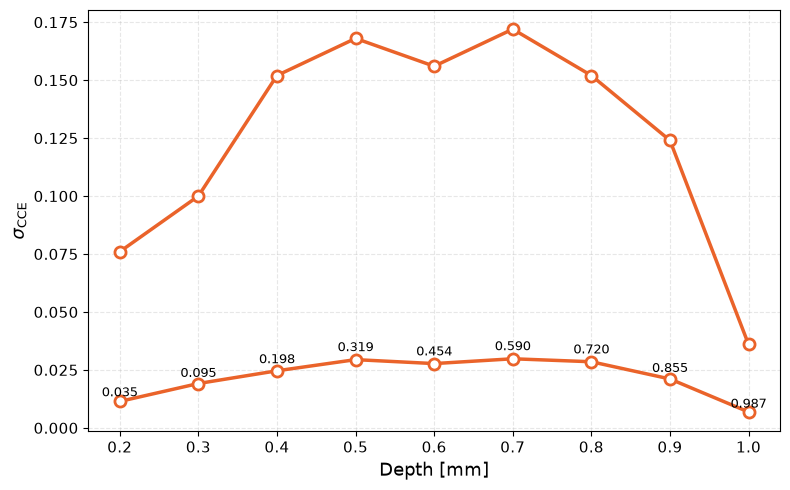

In [45]:

# scegli alcune profondità da visualizzare
depth_indices = np.arange(4,21,2)

# array per salvare le larghezze
CCE_width = []

# colori
colors = plt.colormaps["inferno"](
    np.linspace(0.2, 0.8, len(depth_indices))
)

# stessi bin per tutte le distribuzioni
bins = np.linspace(
    np.min(CCE_matrix),
    np.max(CCE_matrix),
    50
)

plt.figure(figsize=(20,6))

for k, i in enumerate(depth_indices):

    # distribuzione CCE alla profondità i
    cce_dist = CCE_matrix[i, :]

    # larghezza della distribuzione
    sigma = np.std(cce_dist)

    # salva
    CCE_width.append(sigma)

    # plot
    plt.hist(
        cce_dist,
        bins=bins,
        density=True,
        histtype="stepfilled",
        linewidth=2,
        edgecolor=colors[k],
        color=colors[k],
        alpha = 0.7,
        label=f"{x[i]*10:.2f} mm"
    )

    print(
        f"x = {x[i]*10:.3f} mm  -->  sigma_CCE = {sigma:.5f}"
    )


plt.xlabel("CCE")
plt.ylabel("Probability density")
plt.grid(alpha=0.3)

plt.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=6,
    fontsize=10
)

plt.xlim(0,1)
plt.show()
# converto in array
CCE_width = np.array(CCE_width)

# profondità corrispondenti
depth = x[depth_indices]*10   # mm

# stesso colore base degli istogrammi
cmap = plt.colormaps["inferno"]
line_color = cmap(0.65)

plt.figure(figsize=(8,5))

plt.plot(
    depth,
    CCE_width,
    color=line_color,
    linewidth=2.5,
    marker="o",
    markersize=8,
    markerfacecolor="white",
    markeredgewidth=2,
    markeredgecolor=line_color
)
CCE_range = np.ptp(CCE_matrix, axis=1)

plt.plot(
    depth,
    CCE_range[depth_indices],
    color=line_color,
    linewidth=2.5,
    marker="o",
    markersize=8,
    markerfacecolor="white",
    markeredgewidth=2,
    markeredgecolor=line_color
)
# aggiungo i valori sopra i punti
for i, (xi, yi) in enumerate(zip(depth, CCE_width)):
    plt.text(
        xi,
        yi*1.08,
        f"{CCE_mean[depth_indices[i]]:.3f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.xlabel("Depth [mm]", fontsize=13)
plt.ylabel(r"$\sigma_{\mathrm{CCE}}$", fontsize=13)


plt.grid(
    alpha=0.3,
    linestyle="--"
)

plt.tick_params(
    labelsize=11
)

plt.tight_layout()

plt.show()

In [20]:
CCE_width

array([0.0257247 , 0.04089487, 0.05311111, 0.06099106, 0.07068458,
       0.07030782, 0.06497969, 0.0453245 , 0.01518914])

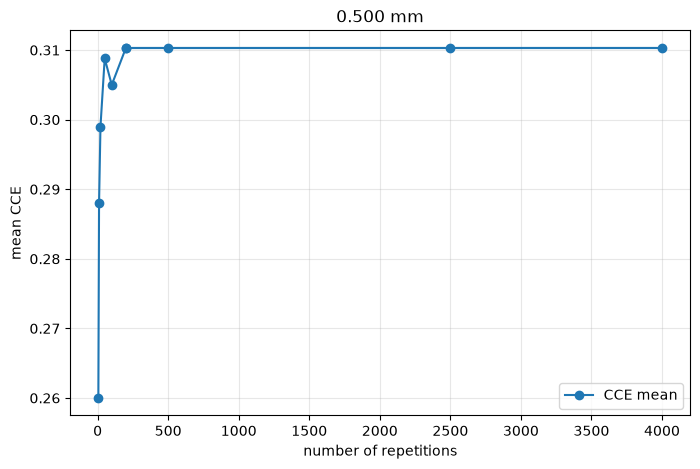

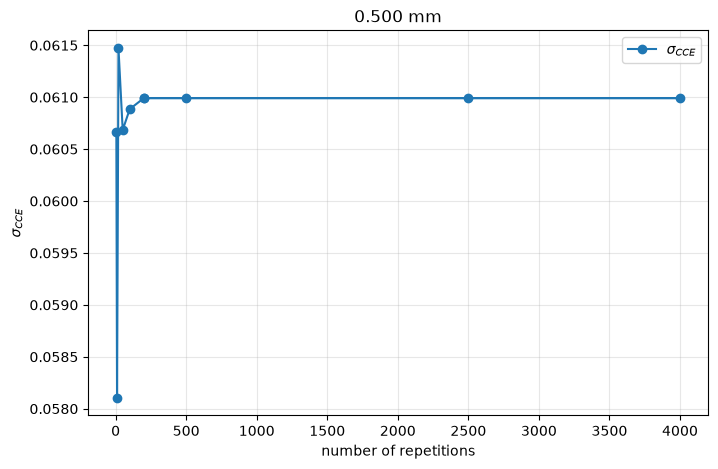

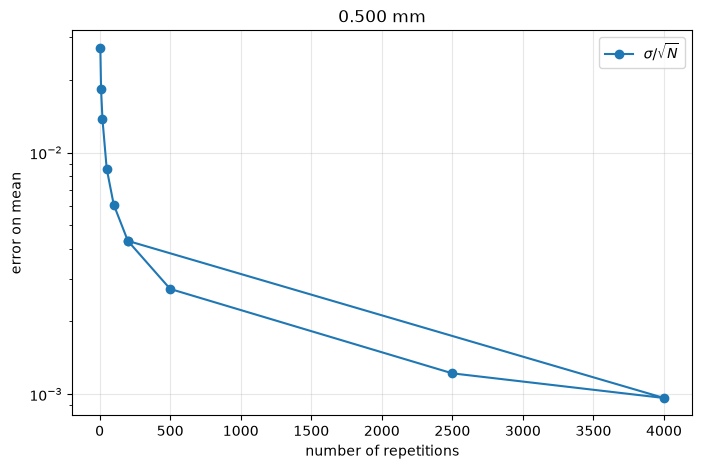

In [21]:
# numero di ripetizioni da testare
N_values = [5, 10, 20, 50, 100, 200, 500, 2500, 4000, CCE_matrix.shape[1]]

# scegli una profondità da monitorare
depth_index = 10   # cambia questo valore


mean_values = []
std_values = []
std_mean_values = []


for N in N_values:

    # prendo solo le prime N simulazioni
    data = CCE_matrix[depth_index, :N]

    # media
    mean = np.mean(data)

    # deviazione standard della distribuzione
    sigma = np.std(data)

    # errore statistico sulla media
    sigma_mean = sigma / np.sqrt(N)

    mean_values.append(mean)
    std_values.append(sigma)
    std_mean_values.append(sigma_mean)



# ----------------------------
# Plot convergenza media
# ----------------------------

plt.figure(figsize=(8,5))

plt.plot(
    N_values,
    mean_values,
    marker="o",
    label="CCE mean"
)
plt.title(f"{x[depth_index]*10:.3f} mm")
plt.xlabel("number of repetitions")
plt.ylabel("mean CCE")
plt.grid(alpha=0.3)
plt.legend()

plt.show()



# ----------------------------
# Plot convergenza sigma
# ----------------------------

plt.figure(figsize=(8,5))

plt.plot(
    N_values,
    std_values,
    marker="o",
    label=r"$\sigma_{CCE}$"
)

plt.xlabel("number of repetitions")
plt.ylabel(r"$\sigma_{CCE}$")
plt.grid(alpha=0.3)
plt.legend()
plt.title(f"{x[depth_index]*10:.3f} mm")
plt.show()



# ----------------------------
# Errore sulla media
# ----------------------------

plt.figure(figsize=(8,5))

plt.plot(
    N_values,
    std_mean_values,
    marker="o",
    label=r"$\sigma/\sqrt{N}$"
)

plt.xlabel("number of repetitions")
plt.ylabel("error on mean")
plt.yscale("log")
plt.grid(alpha=0.3)
plt.legend()
plt.title(f"{x[depth_index]*10:.3f} mm")
plt.show()


In [22]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# PARAMETRI
# ============================================================

# numero di ripetizioni da testare
N_values = [
    5, 10, 20, 50, 100,
    200, 500, 2500, 4000,
    CCE_matrix.shape[1]
]

# profondità da analizzare
depth_index = 8


# array risultati
mean_values = []
std_values = []
std_mean_values = []
range_values = []


# ============================================================
# CALCOLO STATISTICHE
# ============================================================

for N in N_values:

    # prime N simulazioni
    data = CCE_matrix[depth_index, :N]

    # media
    mean = np.mean(data)

    # deviazione standard
    sigma = np.std(data)

    # errore sulla media
    sigma_mean = sigma / np.sqrt(N)

    # massima dispersione
    dispersion = np.max(data) - np.min(data)


    mean_values.append(mean)
    std_values.append(sigma)
    std_mean_values.append(sigma_mean)
    range_values.append(dispersion)




In [23]:

# conversione array
mean_values = np.array(mean_values)
std_values = np.array(std_values)
std_mean_values = np.array(std_mean_values)
range_values = np.array(range_values)




In [24]:

# valori finali con tutte le simulazioni
mean_ref = np.mean(CCE_matrix[depth_index])
sigma_ref = np.std(CCE_matrix[depth_index])

range_ref = (
    np.max(CCE_matrix[depth_index])
    -
    np.min(CCE_matrix[depth_index])
)



# stile
color = plt.colormaps["inferno"](0.65)


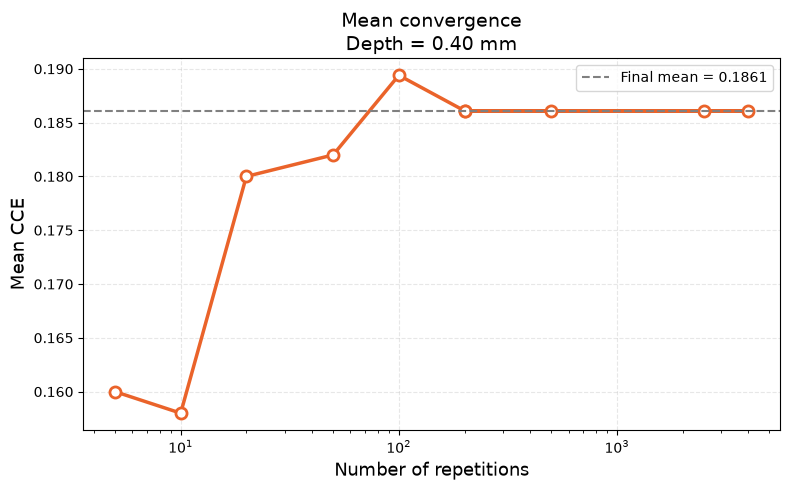

In [25]:


# ============================================================
# 1) CONVERGENZA DELLA MEDIA
# ============================================================

plt.figure(figsize=(8,5))


plt.plot(
    N_values,
    mean_values,
    "-o",
    color=color,
    linewidth=2.5,
    markersize=8,
    markerfacecolor="white",
    markeredgewidth=2
)


plt.axhline(
    mean_ref,
    color="gray",
    linestyle="--",
    linewidth=1.5,
    label=f"Final mean = {mean_ref:.4f}"
)


plt.xscale("log")


plt.xlabel(
    "Number of repetitions",
    fontsize=13
)

plt.ylabel(
    "Mean CCE",
    fontsize=13
)


plt.title(
    f"Mean convergence\nDepth = {x[depth_index]*10:.2f} mm",
    fontsize=14
)


plt.grid(
    alpha=0.3,
    linestyle="--"
)


plt.legend()

plt.tight_layout()

plt.show()


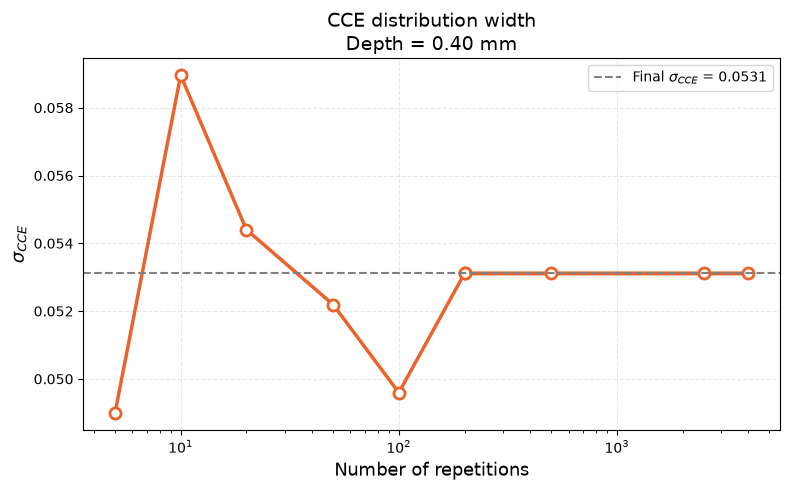

In [26]:
# ============================================================
# 2) CONVERGENZA DELLA DISTRIBUZIONE
# ============================================================

plt.figure(figsize=(8,5))


plt.plot(
    N_values,
    std_values,
    "-o",
    color=color,
    linewidth=2.5,
    markersize=8,
    markerfacecolor="white",
    markeredgewidth=2
)


plt.axhline(
    sigma_ref,
    color="gray",
    linestyle="--",
    linewidth=1.5,
    label=fr"Final $\sigma_{{CCE}}$ = {sigma_ref:.4f}"
)


plt.xscale("log")


plt.xlabel(
    "Number of repetitions",
    fontsize=13
)

plt.ylabel(
    r"$\sigma_{CCE}$",
    fontsize=13
)


plt.title(
    f"CCE distribution width\nDepth = {x[depth_index]*10:.2f} mm",
    fontsize=14
)


plt.grid(
    alpha=0.3,
    linestyle="--"
)


plt.legend()

plt.tight_layout()

plt.show()

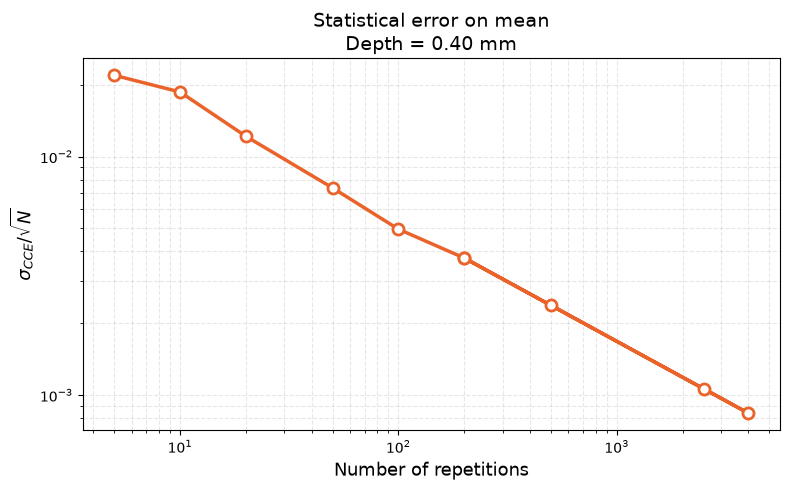

In [27]:

# ============================================================
# 3) ERRORE STATISTICO SULLA MEDIA
# ============================================================

plt.figure(figsize=(8,5))


plt.plot(
    N_values,
    std_mean_values,
    "-o",
    color=color,
    linewidth=2.5,
    markersize=8,
    markerfacecolor="white",
    markeredgewidth=2
)


plt.xscale("log")
plt.yscale("log")


plt.xlabel(
    "Number of repetitions",
    fontsize=13
)

plt.ylabel(
    r"$\sigma_{CCE}/\sqrt{N}$",
    fontsize=13
)


plt.title(
    f"Statistical error on mean\nDepth = {x[depth_index]*10:.2f} mm",
    fontsize=14
)


plt.grid(
    alpha=0.3,
    linestyle="--",
    which="both"
)


plt.tight_layout()

plt.show()


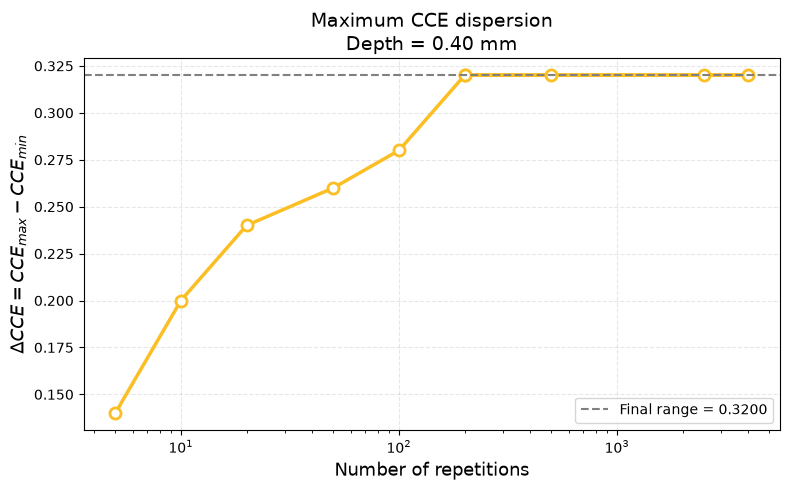

In [28]:
# ============================================================
# 4) MASSIMA DISPERSIONE (MAX-MIN)
# ============================================================

plt.figure(figsize=(8,5))


plt.plot(
    N_values,
    range_values,
    "-o",
    color=plt.colormaps["inferno"](0.85),
    linewidth=2.5,
    markersize=8,
    markerfacecolor="white",
    markeredgewidth=2
)


plt.axhline(
    range_ref,
    color="gray",
    linestyle="--",
    linewidth=1.5,
    label=f"Final range = {range_ref:.4f}"
)


plt.xscale("log")


plt.xlabel(
    "Number of repetitions",
    fontsize=13
)

plt.ylabel(
    r"$\Delta CCE = CCE_{max}-CCE_{min}$",
    fontsize=13
)


plt.title(
    f"Maximum CCE dispersion\nDepth = {x[depth_index]*10:.2f} mm",
    fontsize=14
)


plt.grid(
    alpha=0.3,
    linestyle="--"
)


plt.legend()

plt.tight_layout()

plt.show()

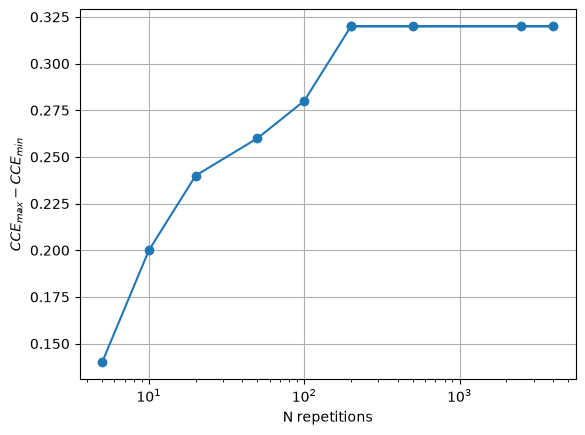

In [29]:
plt.plot(
    N_values,
    range_values,
    marker="o"
)

plt.xscale("log")
plt.xlabel("N repetitions")
plt.ylabel(r"$CCE_{max}-CCE_{min}$")
plt.grid()